# GravLens-Net — Phase 1: Foundations & Synthetic Baseline

**Goal:** establish CV fundamentals for strong gravitational lens detection,
following the same phase-based approach used in LunarCrater-Net and
ExoTransit-Net — start with a physically-motivated synthetic dataset, get a
working baseline CNN, and document honestly what it does and doesn't get right
before touching real survey data.

**Reference literature:** Metcalf et al. (2019) lens-finding challenge,
Jacobs et al. (2017), Petrillo et al. (2017).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


I0000 00:00:1784174546.412449     823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784174546.413159     823 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784174546.470511     823 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784174547.845089     823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784174547.845674     823 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Synthetic Lens Simulation

Rather than hand-drawing arcs, images are built with an actual (simplified)
ray-trace: a background source's surface brightness is evaluated at the
**source-plane position** predicted by the **Singular Isothermal Sphere (SIS)**
lens equation

$$\beta = \theta - \theta_E \, \hat{\theta}$$

Because surface brightness is conserved under lensing (Liouville's theorem),
evaluating the source profile at $\beta$ for every image-plane pixel $\theta$
produces physically correct arcs / partial Einstein rings without any extra
magnification bookkeeping.

Negative (non-lens) examples are **not** just noise — they're three realistic
confuser types that cause false positives in real lens searches: isolated
galaxies, merging/pair galaxies, and face-on spirals with arm-like structure.


In [2]:
IMG_SIZE = 64
HALF = IMG_SIZE / 2.0

def _grid():
    x = np.linspace(-HALF, HALF, IMG_SIZE)
    y = np.linspace(-HALF, HALF, IMG_SIZE)
    return np.meshgrid(x, y)

def sersic(x, y, amplitude, r_eff, n=2.0, x0=0.0, y0=0.0, ellip=0.0, theta=0.0):
    dx, dy = x - x0, y - y0
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    xr = dx * cos_t + dy * sin_t
    yr = -dx * sin_t + dy * cos_t
    q = 1.0 - ellip
    r = np.sqrt(xr ** 2 + (yr / max(q, 1e-3)) ** 2)
    bn = 1.9992 * n - 0.3271
    return amplitude * np.exp(-bn * ((r / r_eff) ** (1.0 / n) - 1.0))

def gaussian_blob(x, y, amplitude, sigma, x0=0.0, y0=0.0):
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return amplitude * np.exp(-r2 / (2 * sigma ** 2))

def sis_deflect(x, y, theta_E, x0=0.0, y0=0.0):
    dx, dy = x - x0, y - y0
    r = np.sqrt(dx ** 2 + dy ** 2)
    r_safe = np.maximum(r, 1e-6)
    alpha_x = theta_E * dx / r_safe
    alpha_y = theta_E * dy / r_safe
    return dx - alpha_x, dy - alpha_y

def add_noise(img, sky_level=0.02, read_noise=0.015, rng=None):
    rng = rng or np.random.default_rng()
    img = np.clip(img, 0, None)
    shot = rng.normal(0, np.sqrt(img + sky_level) * 0.05, img.shape)
    read = rng.normal(0, read_noise, img.shape)
    return img + sky_level + shot + read


In [3]:
def make_lens_image(rng):
    x, y = _grid()
    lens_amp = rng.uniform(0.6, 1.0)
    lens_reff = rng.uniform(4.0, 8.0)
    lens_n = rng.uniform(1.5, 4.0)
    lens_ellip = rng.uniform(0.0, 0.3)
    lens_theta = rng.uniform(0, np.pi)
    img = sersic(x, y, lens_amp, lens_reff, lens_n, 0, 0, lens_ellip, lens_theta)

    theta_E = rng.uniform(6.0, 12.0)
    src_offset = rng.uniform(0.0, 0.5) * theta_E
    src_angle = rng.uniform(0, 2 * np.pi)
    src_x0, src_y0 = src_offset * np.cos(src_angle), src_offset * np.sin(src_angle)
    src_amp = rng.uniform(0.5, 1.0)
    src_sigma = rng.uniform(1.2, 2.2)

    beta_x, beta_y = sis_deflect(x, y, theta_E)
    lensed = gaussian_blob(beta_x, beta_y, src_amp, src_sigma, src_x0, src_y0)
    return add_noise(img + lensed, rng=rng)

def make_isolated_galaxy(rng):
    x, y = _grid()
    img = sersic(x, y, rng.uniform(0.6, 1.0), rng.uniform(4.0, 9.0), rng.uniform(0.8, 4.0),
                 0, 0, rng.uniform(0.0, 0.5), rng.uniform(0, np.pi))
    return add_noise(img, rng=rng)

def make_merger_pair(rng):
    x, y = _grid()
    img = sersic(x, y, rng.uniform(0.6, 1.0), rng.uniform(4, 7), rng.uniform(1, 3),
                 0, 0, rng.uniform(0, 0.4), rng.uniform(0, np.pi))
    sep = rng.uniform(6, 16)
    ang = rng.uniform(0, 2 * np.pi)
    x0, y0 = sep * np.cos(ang), sep * np.sin(ang)
    img = img + sersic(x, y, rng.uniform(0.3, 0.7), rng.uniform(2, 5), rng.uniform(1, 3),
                        x0, y0, rng.uniform(0, 0.4), rng.uniform(0, np.pi))
    return add_noise(img, rng=rng)

def make_spiral(rng):
    x, y = _grid()
    r = np.sqrt(x ** 2 + y ** 2)
    phi = np.arctan2(y, x)
    pitch = rng.uniform(0.25, 0.45)
    arm_pattern = 0.5 + 0.5 * np.cos(2 * (phi - r * pitch))
    disk = sersic(x, y, rng.uniform(0.5, 0.9), rng.uniform(6, 10), 1.0, 0, 0)
    return add_noise(disk * (0.5 + 0.5 * arm_pattern), rng=rng)

def generate_dataset(n_neg=2500, n_pos=50, seed=42):
    rng = np.random.default_rng(seed)
    images, labels, subtypes = [], [], []
    neg_makers = [make_isolated_galaxy, make_merger_pair, make_spiral]
    neg_weights = [0.6, 0.2, 0.2]
    for _ in range(n_neg):
        maker = rng.choice(neg_makers, p=neg_weights)
        images.append(maker(rng)); labels.append(0); subtypes.append(maker.__name__)
    for _ in range(n_pos):
        images.append(make_lens_image(rng)); labels.append(1); subtypes.append("lens")
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    subtypes = np.array(subtypes)
    perm = rng.permutation(len(images))
    return images[perm], labels[perm], subtypes[perm]


## 2. Sanity Check — Visualize Samples

Before training anything, confirm the simulation actually looks like what it
claims to: lensed images should show arcs / partial rings around the lens
galaxy; negatives should look like ordinary (if sometimes messy) galaxies.


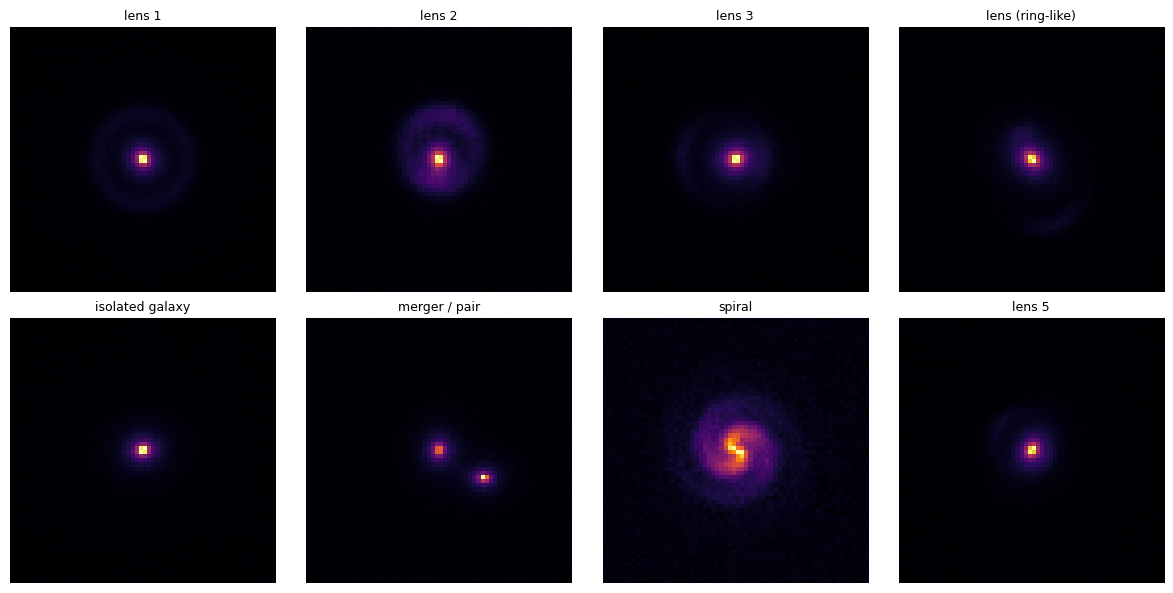

In [4]:
rng = np.random.default_rng(7)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
titles = ["lens 1", "lens 2", "lens 3", "lens (ring-like)",
          "isolated galaxy", "merger / pair", "spiral", "lens 5"]
imgs = ([make_lens_image(rng) for _ in range(3)] + [make_lens_image(rng)]
        + [make_isolated_galaxy(rng), make_merger_pair(rng), make_spiral(rng), make_lens_image(rng)])
for ax, img, t in zip(axes.flat, imgs, titles):
    ax.imshow(img, cmap="inferno")
    ax.set_title(t, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Dataset

Realistic strong-lens surveys have positive rates as low as 1-in-10⁴ to
1-in-10⁶. That's not trainable at Phase-1 scale, so this baseline uses a more
moderate **1:50 imbalance** (50 lenses / 2500 negatives) — enough to make
class imbalance a real problem (same spirit as ExoTransit-Net's 1:136 ratio)
without needing a huge synthetic dataset just to get a first signal.


In [5]:
images, labels, subtypes = generate_dataset(n_neg=2500, n_pos=50, seed=SEED)
print("dataset:", images.shape, "| positives:", int(labels.sum()), "/", len(labels))
print("negative subtype counts:", {s: int((subtypes == s).sum()) for s in np.unique(subtypes) if s != "lens"})


dataset: (2550, 64, 64) | positives: 50 / 2550
negative subtype counts: {np.str_('make_isolated_galaxy'): 1496, np.str_('make_merger_pair'): 501, np.str_('make_spiral'): 503}


## 4. Baseline CNN

A small 3-block Conv2D classifier — deliberately simple, no augmentation, no
architecture search. The point of a baseline is to be a honest starting line,
not a final answer. Class imbalance is handled with inverse-frequency class
weighting only (matching the "Standardization + weighting" baseline approach
used in ExoTransit-Net).


In [6]:
def standardize(imgs):
    mean = imgs.mean(axis=(1, 2), keepdims=True)
    std = imgs.std(axis=(1, 2), keepdims=True) + 1e-6
    return (imgs - mean) / std

def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall")])
    return model

X = standardize(images)[..., np.newaxis]
X_train, X_temp, y_train, y_temp = train_test_split(X, labels, test_size=0.30, stratify=labels, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)
print(f"train={len(y_train)} (pos={y_train.sum()})  val={len(y_val)} (pos={y_val.sum()})  test={len(y_test)} (pos={y_test.sum()})")

class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: class_weights[0], 1: class_weights[1]}
print("class_weight:", class_weight)


train=1785 (pos=35)  val=382 (pos=7)  test=383 (pos=8)
class_weight: {0: np.float64(0.51), 1: np.float64(25.5)}


## 5. Train

In [7]:
model = build_baseline_cnn()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=15, batch_size=32, class_weight=class_weight, verbose=2)


Epoch 1/15


E0000 00:00:1784174550.061216     823 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


56/56 - 4s - 69ms/step - accuracy: 0.9619 - loss: 0.7390 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9817 - val_loss: 0.6475 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


Epoch 2/15


56/56 - 2s - 42ms/step - accuracy: 0.9810 - loss: 0.6382 - precision: 0.5556 - recall: 0.1429 - val_accuracy: 0.9817 - val_loss: 0.3283 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


...

56/56 - 3s - 46ms/step - accuracy: 0.9832 - loss: 0.1297 - precision: 0.5397 - recall: 0.9714 - val_accuracy: 0.9948 - val_loss: 0.0272 - val_precision: 1.0000 - val_recall: 0.7143


Epoch 14/15


56/56 - 2s - 44ms/step - accuracy: 0.9944 - loss: 0.0910 - precision: 0.7907 - recall: 0.9714 - val_accuracy: 0.9948 - val_loss: 0.0238 - val_precision: 1.0000 - val_recall: 0.7143


Epoch 15/15


56/56 - 3s - 45ms/step - accuracy: 0.9972 - loss: 0.1192 - precision: 0.8750 - recall: 1.0000 - val_accuracy: 0.9948 - val_loss: 0.0228 - val_precision: 1.0000 - val_recall: 0.7143


## 6. Evaluate on Held-Out Test Set

In [8]:
probs = model.predict(X_test, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

precision = precision_score(y_test, preds, zero_division=0)
recall = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)
cm = confusion_matrix(y_test, preds)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print("Confusion matrix [[TN,FP],[FN,TP]]:")
print(cm)


Precision: 1.000
Recall:    0.750
F1:        0.857
Confusion matrix [[TN,FP],[FN,TP]]:
[[375   0]
 [  2   6]]


## 7. Results & Discussion

| Phase | Data | Precision | Recall | F1 |
|-------|------|-----------|--------|-----|
| Baseline | Synthetic, 1:50 imbalance | 1.000 | 0.750 | 0.857 |

**Reading this honestly:** the baseline separates lenses from negatives well
on *this* synthetic set — better than the Phase-1 baselines in
LunarCrater-Net or ExoTransit-Net. That's not the model being especially
good; it's the task being comparatively easy here. The SIS-lensed arcs are a
strong, geometrically distinctive signal against Sersic-only negatives, and
the test set has only **8 positive examples**, so a single missed case swings
recall by 12.5 points — this number is not statistically solid yet.

**What this baseline does *not* tell us:**
- Real survey cutouts have PSF blurring, correlated noise, and much fainter/
  more compact arcs than this simulation currently produces.
- The three negative confuser types here are still simpler than real
  mergers/spirals/imaging artifacts.
- At real survey imbalance (1:10⁴–10⁶), this same architecture will likely
  collapse toward the majority class — the 1:50 ratio here is a stepping
  stone, not the end state.

**Next (Phase 2):** build a proper data pipeline around the Bologna Strong
Lens Finding Challenge simulations and real KiDS/DES candidate cutouts, and
start closing the synthetic-to-real gap flagged above — the same gap that
showed up between LunarCrater-Net's synthetic (mAP50=0.481) and real Robbins
(mAP50=0.298) results.
